In [13]:
import matplotlib.pyplot as plt
import numpy as np


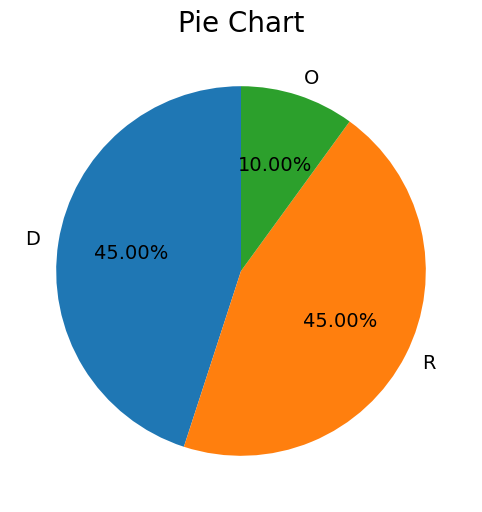

In [7]:
labels = ['D', 'R', 'O']
samples = [9, 9, 2]

plt.figure(figsize=(8, 6))
plt.pie(labels=labels, x=samples, autopct='%1.2f%%', startangle=90, textprops={'fontsize': 14})
# plt.axis('equal')
plt.title('Pie Chart', fontsize=20)
plt.show()

<Figure size 600x400 with 0 Axes>

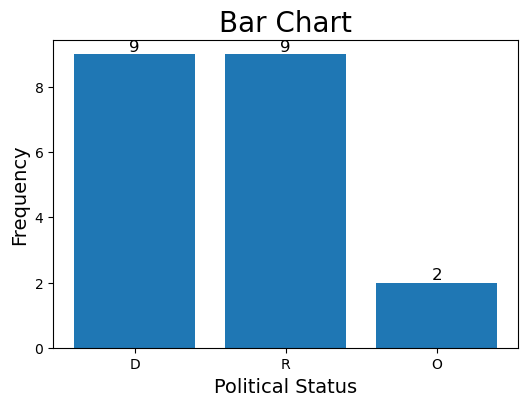

In [6]:
plt.figure(figsize=(6,4))
plt.figure(figsize=(6,4))
bars = plt.bar(labels, samples)
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{int(h)}',
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.xlabel('Political Status', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Bar Chart', fontsize=20)
plt.show()

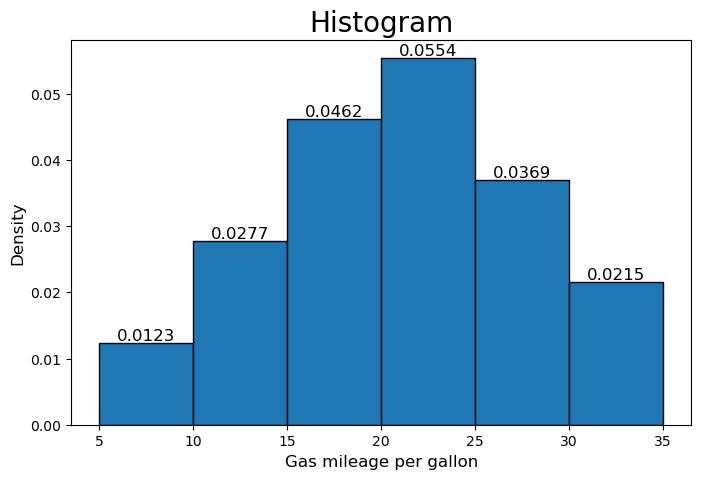

In [5]:
bins = [5, 10, 15, 20, 25, 30, 35]
densities = [0.0123, 0.0277, 0.0462, 0.0554, 0.0369, 0.0215]

left_edges = bins[:-1]
widths = [bins[i+1] - bins[i] for i in range(len(bins)-1)]

plt.figure(figsize=(8, 5))
plt.bar(left_edges, densities, width=widths, align='edge', edgecolor='black')

for left, width, h in zip(left_edges, widths, densities):
    plt.text(left + width/2, h, f'{h:.4f}', ha='center', va='bottom', fontsize=12)

plt.xlabel('Gas mileage per gallon', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Histogram', fontsize=20)
plt.xticks(bins)
plt.show()

In [12]:
data = [5.6, 2.5, 3.7, 7.9, 11.3, 6.4, 3.2, 2.7, 0.5, 5.7, 3.2, 2.4, 7.6, 3.8, 5.7, 5.8, 3.4, 5.1, 2.2, 4.0, 4.2, 4.2,
        5.5, 1.5, 1.6, 6.3, 4.3, 5.0, 8.6, 6.3, 4.3, 6.4, 4.6, 2.0, 4.4]

print(sum(data))

161.9


In [16]:
x = np.array([
    5.6, 2.5, 3.7, 7.9, 11.3, 6.4, 3.2, 2.7, 0.5, 5.7,
    3.2, 2.4, 7.6, 3.8, 5.7, 5.8, 3.4, 5.1, 2.2, 4.0,
    4.2, 4.2, 5.5, 1.5, 1.6, 6.3, 4.3, 5.0, 8.6, 6.3,
    4.3, 6.4, 4.6, 2.0, 4.4])

B = 1000
n = len(x)
np.random.seed(611211106)

def theta_from_mean(m):
    return m * (m + 1)

theta = np.empty(B)

for b in range(B):
    sample = np.random.choice(x, size=n, replace=True)
    mean = np.mean(sample)
    theta[b] = theta_from_mean(mean)

lower = np.percentile(theta, 2.5)
upper = np.percentile(theta, 97.5)

print(f"95% bootstrap CI for theta = ({lower:.4f}, {upper:.4f})")

95% bootstrap CI for theta = (19.5137, 34.2572)


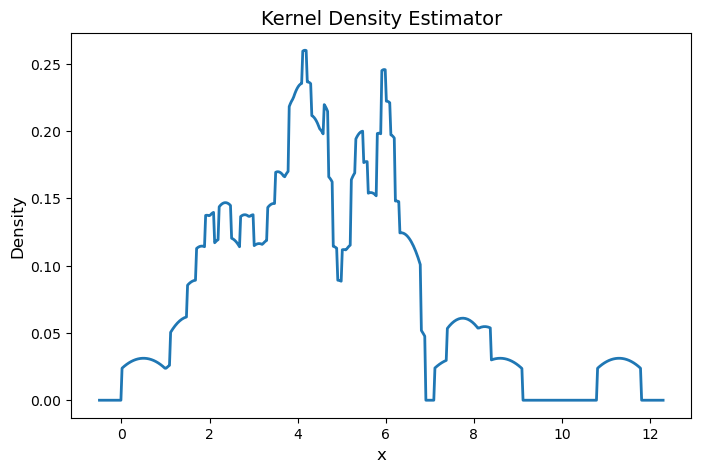

In [ ]:
data = np.array([
    5.6, 2.5, 3.7, 7.9, 11.3, 6.4, 3.2, 2.7, 0.5, 5.7,
    3.2, 2.4, 7.6, 3.8, 5.7, 5.8, 3.4, 5.1, 2.2, 4.0,
    4.2, 4.2, 5.5, 1.5, 1.6, 6.3, 4.3, 5.0, 8.6, 6.3,
    4.3, 6.4, 4.6, 2.0, 4.4])
n = len(data)
h = 1.0
# Epanechnikov kernel
def epanechnikov(u):
    return np.where(np.abs(u)<=0.5, 12/11*(1-u**2), 0.0)

def kde_epanechnikov(x, data, h):
    u = (x[:, None]-data[None, :])/h
    return np.sum(epanechnikov(u), axis=1)/(len(data)*h)

x_grid = np.linspace(min(data)-1, max(data)+1, 500)
y_kde = kde_epanechnikov(x_grid, data, h)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, y_kde, linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Kernel Density Estimator', fontsize=14)
plt.show()